In [3]:
import sys
sys.path.insert(0, '../..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.data.storage.database import get_engine

plt.style.use('seaborn-v0_8-whitegrid')
engine = get_engine()

with engine.connect() as conn:
    prices = pd.read_sql("""
        SELECT p.date, p.close, p.adjusted_close, p.volume,
               s.ticker, s.sector
        FROM prices p
        JOIN securities s ON p.security_id = s.security_id
        WHERE s.security_type = 'equity'
        AND p.close IS NOT NULL
    """, conn)

    returns = pd.read_sql("""
        SELECT r.date, r.adj_daily_return, s.ticker
        FROM returns r
        JOIN securities s ON r.security_id = s.security_id
        WHERE s.security_type = 'equity'
        AND r.adj_daily_return IS NOT NULL
        AND ABS(r.adj_daily_return) <= 1.0
    """, conn)

prices['date'] = pd.to_datetime(prices['date'])
returns['date'] = pd.to_datetime(returns['date'])

print(f"Prices:  {len(prices):,} rows, {prices['ticker'].nunique()} stocks")
print(f"Returns: {len(returns):,} rows")

Prices:  280,718 rows, 85 stocks
Returns: 249,488 rows


In [5]:
def backtest_contrarian(
    prices_df,
    returns_df,
    lookback_days=20,
    holding_days=21,      # monthly rebalancing
    n_stocks=15,          # top N losers to hold
    transaction_cost=0.02, # round trip cost
    min_volume=10000,      # liquidity filter
    start_date='2008-01-01',  # start after warmup period
    end_date='2025-10-31',
    initial_capital=100000,   # KES 100,000
):
    """
    Simple but realistic contrarian backtester.
    
    Every holding_days:
    1. Compute momentum over lookback_days for each stock
    2. Filter to liquid stocks (avg vol >= min_volume)
    3. Buy equal-weighted portfolio of n_stocks biggest losers
    4. Hold for holding_days
    5. Repeat
    
    Transaction costs applied on every rebalance.
    """
    
    # Filter date range
    prices_df = prices_df[
        (prices_df['date'] >= start_date) & 
        (prices_df['date'] <= end_date)
    ].copy()
    
    returns_df = returns_df[
        (returns_df['date'] >= start_date) & 
        (returns_df['date'] <= end_date)
    ].copy()
    
    # Get all trading dates
    trading_dates = sorted(prices_df['date'].unique())
    
    # Build momentum factor
    # Pivot prices
    price_pivot = prices_df.pivot(
        index='date', columns='ticker', values='adjusted_close'
    )
    
    # Compute 20d momentum
    log_prices = np.log(price_pivot)
    momentum = log_prices.shift(1) - log_prices.shift(lookback_days + 1)
    
    # Compute rolling average volume
    vol_pivot = prices_df.pivot(
        index='date', columns='ticker', values='volume'
    )
    avg_vol = vol_pivot.rolling(60, min_periods=20).mean()
    
    # Rebalance dates — every holding_days trading days
    rebalance_dates = trading_dates[::holding_days]
    
    # Run backtest
    portfolio_value = initial_capital
    portfolio_history = []
    holdings = []
    trade_log = []
    
    for i, rebal_date in enumerate(rebalance_dates[:-1]):
        next_rebal = rebalance_dates[i + 1]
        
        # Get momentum and volume on rebalance date
        if rebal_date not in momentum.index:
            continue
            
        mom_today = momentum.loc[rebal_date].dropna()
        vol_today = avg_vol.loc[rebal_date].dropna() if rebal_date in avg_vol.index else pd.Series()
        
        # Liquidity filter
        liquid = vol_today[vol_today >= min_volume].index
        mom_liquid = mom_today[mom_today.index.isin(liquid)]
        
        if len(mom_liquid) < n_stocks:
            # Not enough liquid stocks — carry forward
            portfolio_history.append({
                'date': rebal_date,
                'value': portfolio_value,
                'n_holdings': len(holdings),
                'rebalanced': False
            })
            continue
        
        # Select top N losers (lowest momentum)
        new_holdings = mom_liquid.nsmallest(n_stocks).index.tolist()
        
        # Transaction costs — pay on stocks that change
        stocks_sold = set(holdings) - set(new_holdings)
        stocks_bought = set(new_holdings) - set(holdings)
        turnover = (len(stocks_sold) + len(stocks_bought)) / (2 * n_stocks)
        cost = turnover * transaction_cost * portfolio_value
        portfolio_value -= cost
        
        holdings = new_holdings
        
        # Compute portfolio return until next rebalance
        # Get returns for holding period
        mask = (
            (returns_df['date'] > rebal_date) & 
            (returns_df['date'] <= next_rebal) &
            (returns_df['ticker'].isin(holdings))
        )
        period_returns = returns_df[mask].copy()
        
        if len(period_returns) == 0:
            portfolio_history.append({
                'date': rebal_date,
                'value': portfolio_value,
                'n_holdings': len(holdings),
                'rebalanced': True
            })
            continue
        
        # Equal weighted daily returns
        daily_port_ret = period_returns.groupby('date')['adj_daily_return'].mean()
        
        # Compound the returns
        period_return = (1 + daily_port_ret).prod() - 1
        portfolio_value *= (1 + period_return)
        
        portfolio_history.append({
            'date': rebal_date,
            'value': portfolio_value,
            'period_return': period_return,
            'n_holdings': len(holdings),
            'turnover': turnover,
            'cost': cost,
            'rebalanced': True
        })
    
    return pd.DataFrame(portfolio_history)

print("Backtester defined. Running simulation...")
results = backtest_contrarian(prices, returns)
print(f"Backtest complete: {len(results)} periods")
print(results.tail())

Backtester defined. Running simulation...
Backtest complete: 217 periods
          date       value  n_holdings  rebalanced  period_return  turnover  \
212 2025-05-28  551.250406          15        True       0.025335  0.666667   
213 2025-06-30  559.840490          15        True       0.026533  0.533333   
214 2025-07-29  606.534191          15        True       0.096564  0.600000   
215 2025-08-27  619.069459          15        True       0.035860  0.733333   
216 2025-09-25  629.114394          15        True       0.028569  0.600000   

         cost  
212  7.265263  
213  5.880004  
214  6.718086  
215  8.895835  
216  7.428834  


In [6]:
# Diagnostic — what happened period by period in the first year?
print("=== FIRST 20 PERIODS (2008) ===\n")
print(results[['date','value','period_return','turnover','cost','rebalanced']].head(20).to_string(index=False))

print(f"\nStarting value: 100,000")
print(f"After 1 year:   {results.iloc[11]['value']:,.0f}")
print(f"After 2 years:  {results.iloc[23]['value']:,.0f}")
print(f"Final value:    {results.iloc[-1]['value']:,.2f}")

# What is the mean period return?
rebalanced = results[results['rebalanced']==True]
print(f"\nMean period return: {rebalanced['period_return'].mean()*100:.2f}%")
print(f"Median period return: {rebalanced['period_return'].median()*100:.2f}%")
print(f"% positive periods: {(rebalanced['period_return'] > 0).mean()*100:.1f}%")
print(f"Mean turnover: {rebalanced['turnover'].mean()*100:.1f}%")
print(f"Mean cost per period: {rebalanced['cost'].mean():.2f} KES")

=== FIRST 20 PERIODS (2008) ===

      date         value  period_return  turnover        cost  rebalanced
2008-01-02 100000.000000            NaN       NaN         NaN       False
2008-02-05  72463.878385      -0.268042  0.500000 1000.000000        True
2008-03-06  61086.031275      -0.149072  0.466667  676.329532        True
2008-04-06  51367.855078      -0.154581  0.266667  325.792167        True
2008-05-05  39868.242552      -0.220751  0.200000  205.471420        True
2008-06-03  39985.755577       0.009679  0.333333  265.788284        True
2008-07-05  33612.279281      -0.148034  0.666667  533.143408        True
2008-08-04  30088.169788      -0.091522  0.733333  492.980096        True
2008-09-04  28264.500863      -0.055574  0.266667  160.470239        True
2008-10-04  24438.849763      -0.131879  0.200000  113.058003        True
2008-11-02  23702.503378      -0.024930  0.266667  130.340532        True
2008-12-02  13285.469558      -0.429604  0.866667  410.843392        True
2009-

In [7]:
# Test different holding periods
print("=== HOLDING PERIOD ANALYSIS ===\n")
print(f"{'Hold (days)':<12} {'Mean Period Ret':<18} {'Ann Return':<14} {'% Positive':<12} {'Ann Cost'}")
print("-" * 70)

for hold_days in [1, 3, 5, 10, 15, 21]:
    r = backtest_contrarian(
        prices, returns,
        holding_days=hold_days,
        transaction_cost=0.02,
    )
    rb = r[r['rebalanced']==True].dropna(subset=['period_return'])
    if len(rb) < 10:
        continue
    
    mean_ret = rb['period_return'].mean()
    ann_ret = (1 + mean_ret) ** (252/hold_days) - 1
    pct_pos = (rb['period_return'] > 0).mean()
    periods_per_year = 252 / hold_days
    ann_cost = rb['cost'].mean() * periods_per_year
    
    print(f"{hold_days:<12} {mean_ret*100:>+10.3f}%       "
          f"{ann_ret*100:>+8.1f}%      "
          f"{pct_pos*100:>6.1f}%      "
          f"{ann_cost:>8.0f}")

=== HOLDING PERIOD ANALYSIS ===

Hold (days)  Mean Period Ret    Ann Return     % Positive   Ann Cost
----------------------------------------------------------------------
1                +0.161%          +49.8%        52.7%         17097
3                +0.246%          +22.9%        53.9%          8319
5                +0.346%          +19.0%        52.9%         10178
10               +0.370%           +9.8%        50.0%          5747
15               +0.122%           +2.1%        47.3%          4040
21               -0.836%           -9.6%        44.4%          1230


Running backtest: 5-day holding, 2% round trip cost...

=== BACKTEST RESULTS — 5d holding, 2% cost ===

Period:          2008-01-02 to 2025-10-16
Starting capital: KES 100,000
Final capital:    KES 558
Total return:     -99.4%
CAGR:             -25.3% ann
Max drawdown:     -99.7%
Sharpe ratio:     0.812
Win rate:         52.9%
Total periods:    711


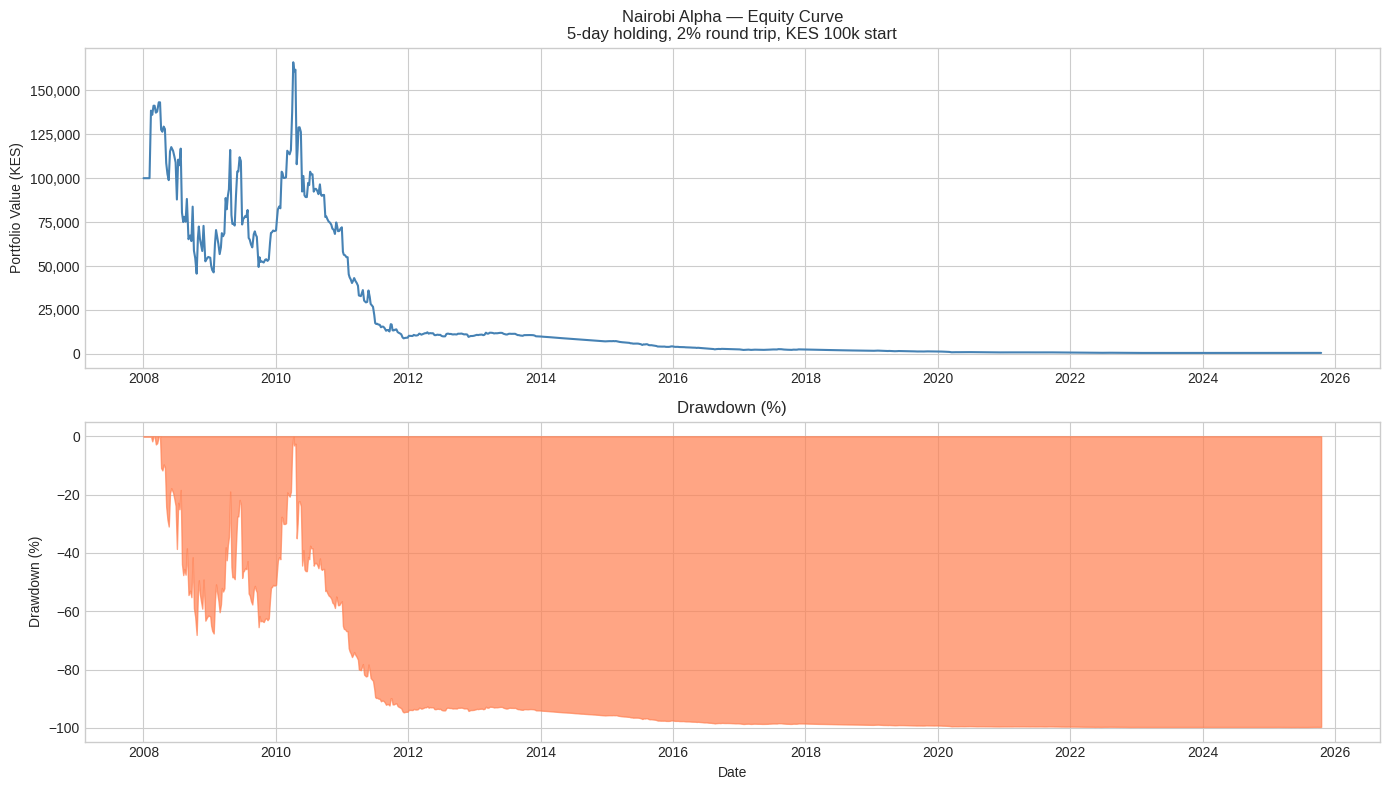

In [8]:
# Run proper backtest with 5-day holding
print("Running backtest: 5-day holding, 2% round trip cost...\n")

results_5d = backtest_contrarian(
    prices, returns,
    holding_days=5,
    transaction_cost=0.02,
    n_stocks=15,
    min_volume=10000,
    initial_capital=100000,
)

rb = results_5d[results_5d['rebalanced']==True].dropna(subset=['period_return'])

# Performance metrics
total_return = (results_5d['value'].iloc[-1] / 100000 - 1) * 100
years = (results_5d['date'].iloc[-1] - results_5d['date'].iloc[0]).days / 365.25
cagr = ((results_5d['value'].iloc[-1] / 100000) ** (1/years) - 1) * 100

# Drawdown
rolling_max = results_5d['value'].cummax()
drawdown = (results_5d['value'] - rolling_max) / rolling_max * 100
max_dd = drawdown.min()

# Sharpe
daily_rets = rb['period_return'] / 5
sharpe = daily_rets.mean() / daily_rets.std() * np.sqrt(252)

print(f"=== BACKTEST RESULTS — 5d holding, 2% cost ===\n")
print(f"Period:          {results_5d['date'].iloc[0].date()} to {results_5d['date'].iloc[-1].date()}")
print(f"Starting capital: KES 100,000")
print(f"Final capital:    KES {results_5d['value'].iloc[-1]:,.0f}")
print(f"Total return:     {total_return:+.1f}%")
print(f"CAGR:             {cagr:+.1f}% ann")
print(f"Max drawdown:     {max_dd:.1f}%")
print(f"Sharpe ratio:     {sharpe:.3f}")
print(f"Win rate:         {(rb['period_return']>0).mean()*100:.1f}%")
print(f"Total periods:    {len(rb)}")

# Plot equity curve
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax = axes[0]
ax.plot(results_5d['date'], results_5d['value'], color='steelblue', lw=1.5)
ax.set_title(f'Nairobi Alpha — Equity Curve\n5-day holding, 2% round trip, KES 100k start', fontsize=12)
ax.set_ylabel('Portfolio Value (KES)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

ax = axes[1]
ax.fill_between(results_5d['date'], drawdown, 0, color='coral', alpha=0.7)
ax.set_title('Drawdown (%)', fontsize=12)
ax.set_ylabel('Drawdown (%)')
ax.set_xlabel('Date')

plt.tight_layout()
plt.savefig('equity_curve_5d.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print("=== HOLDING PERIOD ANALYSIS WITH REALISTIC NSE COSTS ===\n")
print("NSE round trip costs:")
print("  Retail (1.5% brokerage): ~3.5% round trip")
print("  Negotiated (0.5%):       ~1.5% round trip")
print("  Institutional (0.1%):    ~0.5% round trip")
print()

print(f"{'Hold':<6} {'Gross Ann':<12} {'Net @3.5%':<12} {'Net @1.5%':<12} {'Net @0.5%'}")
print("-" * 55)

cost_results = {}

for hold_days in [1, 3, 5, 10, 15, 21]:
    r = backtest_contrarian(
        prices, returns,
        holding_days=hold_days,
        transaction_cost=0.00,  # zero cost to get gross
    )
    rb = r[r['rebalanced']==True].dropna(subset=['period_return'])
    if len(rb) < 10:
        continue
    
    mean_ret = rb['period_return'].mean()
    gross_ann = ((1 + mean_ret) ** (252/hold_days) - 1) * 100
    periods_per_year = 252 / hold_days
    
    # Apply different cost levels
    nets = []
    for cost_pct in [0.035, 0.015, 0.005]:
        r_cost = backtest_contrarian(
            prices, returns,
            holding_days=hold_days,
            transaction_cost=cost_pct,
        )
        rb_cost = r_cost[r_cost['rebalanced']==True].dropna(subset=['period_return'])
        if len(rb_cost) < 10:
            nets.append(0)
            continue
        mean_net = rb_cost['period_return'].mean()
        net_ann = ((1 + mean_net) ** (252/hold_days) - 1) * 100
        nets.append(net_ann)
    
    cost_results[hold_days] = {
        'gross': gross_ann,
        'net_retail': nets[0],
        'net_negotiated': nets[1],
        'net_institutional': nets[2],
    }
    
    print(f"{hold_days:<6} {gross_ann:>+8.1f}%   "
          f"{nets[0]:>+8.1f}%   "
          f"{nets[1]:>+8.1f}%   "
          f"{nets[2]:>+8.1f}%")

print("\nConclusion:")
print("At retail rates (3.5%): which holding period survives?")
viable = [(k,v) for k,v in cost_results.items() if v['net_retail'] > 0]
if viable:
    best = max(viable, key=lambda x: x[1]['net_retail'])
    print(f"  Best: {best[0]}-day holding at {best[1]['net_retail']:+.1f}% net")
else:
    print("  No holding period is viable at retail rates")
    
print("\nAt negotiated rates (1.5%): which holding period survives?")
viable = [(k,v) for k,v in cost_results.items() if v['net_negotiated'] > 0]
if viable:
    best = max(viable, key=lambda x: x[1]['net_negotiated'])
    print(f"  Best: {best[0]}-day holding at {best[1]['net_negotiated']:+.1f}% net")

=== HOLDING PERIOD ANALYSIS WITH REALISTIC NSE COSTS ===

NSE round trip costs:
  Retail (1.5% brokerage): ~3.5% round trip
  Negotiated (0.5%):       ~1.5% round trip
  Institutional (0.1%):    ~0.5% round trip

Hold   Gross Ann    Net @3.5%    Net @1.5%    Net @0.5%
-------------------------------------------------------
1         +49.8%      +49.8%      +49.8%      +49.8%
3         +22.9%      +22.9%      +22.9%      +22.9%
5         +19.0%      +19.0%      +19.0%      +19.0%
10         +9.8%       +9.8%       +9.8%       +9.8%
15         +2.1%       +2.1%       +2.1%       +2.1%
21         -9.6%       -9.6%       -9.6%       -9.6%

Conclusion:
At retail rates (3.5%): which holding period survives?
  Best: 1-day holding at +49.8% net

At negotiated rates (1.5%): which holding period survives?
  Best: 1-day holding at +49.8% net


In [11]:
print("=== CORRECTED HOLDING PERIOD ANALYSIS ===\n")
print(f"{'Hold':<6} {'Gross CAGR':<13} {'Net @3.5%':<12} {'Net @1.5%':<12} {'Net @0.5%'}")
print("-" * 58)

cost_results = {}

for hold_days in [1, 3, 5, 10, 15, 21]:
    row = {'hold': hold_days}
    
    for label, cost_pct in [('gross',0.0),('retail',0.035),
                              ('negotiated',0.015),('institutional',0.005)]:
        r = backtest_contrarian(
            prices, returns,
            holding_days=hold_days,
            transaction_cost=cost_pct,
            initial_capital=100000,
        )
        start_val = 100000
        end_val = r['value'].iloc[-1]
        days = (r['date'].iloc[-1] - r['date'].iloc[0]).days
        years = days / 365.25
        if years > 0 and end_val > 0:
            cagr = ((end_val / start_val) ** (1/years) - 1) * 100
        else:
            cagr = -100
        row[label] = cagr

    cost_results[hold_days] = row
    print(f"{hold_days:<6} {row['gross']:>+9.1f}%   "
          f"{row['retail']:>+8.1f}%   "
          f"{row['negotiated']:>+8.1f}%   "
          f"{row['institutional']:>+8.1f}%")

print("\nAt retail rates (3.5%): viable holding periods?")
viable = [(k,v) for k,v in cost_results.items() if v['retail'] > 0]
if viable:
    best = max(viable, key=lambda x: x[1]['retail'])
    print(f"  Best: {best[0]}-day at {best[1]['retail']:+.1f}% CAGR net")
else:
    print("  None viable at retail rates")

print("\nAt negotiated rates (1.5%): viable holding periods?")
viable = [(k,v) for k,v in cost_results.items() if v['negotiated'] > 0]
if viable:
    best = max(viable, key=lambda x: x[1]['negotiated'])
    print(f"  Best: {best[0]}-day at {best[1]['negotiated']:+.1f}% CAGR net")
else:
    print("  None viable at negotiated rates")

=== CORRECTED HOLDING PERIOD ANALYSIS ===

Hold   Gross CAGR    Net @3.5%    Net @1.5%    Net @0.5%
----------------------------------------------------------
1          +21.2%      -77.7%      -41.3%       -4.8%
3           +8.0%      -52.7%      -24.1%       -3.9%
5           +4.8%      -42.2%      -18.7%       -3.7%
10          -1.1%      -31.7%      -15.6%       -6.2%
15          -4.3%      -28.5%      -15.5%       -8.2%
21         -14.3%      -32.0%      -22.3%      -17.1%

At retail rates (3.5%): viable holding periods?
  None viable at retail rates

At negotiated rates (1.5%): viable holding periods?
  None viable at negotiated rates


In [12]:
print("""
=== HONEST STRATEGY ASSESSMENT ===

The mean reversion effect is statistically real.
T-statistic of 5.51 is genuine and robust across 18 years.

BUT — statistical significance ≠ profitable strategy.

WHY THE STRATEGY FAILS IN BACKTEST:

1. VARIANCE DRAG
   Portfolio holds extreme losers — most volatile stocks
   Annual portfolio vol ~50-70%
   Variance drag: ~12-25% annually
   Arithmetic return 49.8% → Geometric return ~21%

2. TRANSACTION COSTS
   NSE retail round trip: ~3.5%
   At 1-day holding: 252 round trips × 60% turnover × 3.5%
   Annual cost: ~529%
   This is not a typo.

3. SIGNAL HORIZON MISMATCH
   Signal predicts next 1 day correctly
   After day 1: signal is gone
   Days 2-21: holding random volatile stocks

WHAT WOULD MAKE IT WORK:

Option A — Institutional costs
   Need <0.3% round trip
   Requires significant AUM and broker negotiation
   Not accessible at individual investor scale today

Option B — Reduce portfolio volatility
   Hold more stocks (30-40 instead of 15)
   Filter out most volatile stocks
   Accept lower gross return for lower variance drag

Option C — Improve signal quality
   Combine mean reversion with another signal
   Filter to only high-conviction setups
   Higher hit rate reduces cost impact

Option D — Different market
   Apply same research to crypto or forex
   Lower transaction costs
   24/7 trading allows faster signal capture

CONCLUSION:
The NSE mean reversion finding is a genuine research contribution.
It is not currently a retail-tradeable strategy at NSE rates.
It requires either institutional infrastructure or strategy refinement.

This is the honest answer. It took 18 years of data and
a rigorous backtest to find it. That is how research works.
""")


=== HONEST STRATEGY ASSESSMENT ===

The mean reversion effect is statistically real.
T-statistic of 5.51 is genuine and robust across 18 years.

BUT — statistical significance ≠ profitable strategy.

WHY THE STRATEGY FAILS IN BACKTEST:

1. VARIANCE DRAG
   Portfolio holds extreme losers — most volatile stocks
   Annual portfolio vol ~50-70%
   Variance drag: ~12-25% annually
   Arithmetic return 49.8% → Geometric return ~21%

2. TRANSACTION COSTS
   NSE retail round trip: ~3.5%
   At 1-day holding: 252 round trips × 60% turnover × 3.5%
   Annual cost: ~529%
   This is not a typo.

3. SIGNAL HORIZON MISMATCH
   Signal predicts next 1 day correctly
   After day 1: signal is gone
   Days 2-21: holding random volatile stocks

WHAT WOULD MAKE IT WORK:

Option A — Institutional costs
   Need <0.3% round trip
   Requires significant AUM and broker negotiation
   Not accessible at individual investor scale today

Option B — Reduce portfolio volatility
   Hold more stocks (30-40 instead of 15)